In [29]:
include("PermBasis.jl")
include("PlotSetup.jl")
using PyPlot
using DiffEqCallbacks

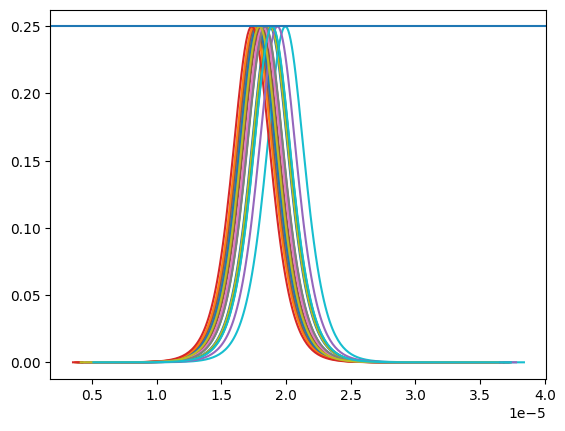

In [ ]:
using Random

const GLOBAL_RNG = Xoshiro(1234)

valid(s,m) = abs(m) <= s || isapprox(s, m, atol=1e-5)
mvals(N) = range(-N/2, N/2)
svals(N) = collect(0:N÷2)

function P_JM_z_minus2(J, M, N)
    if J == 0
        return 0.0
    end
    return (N + 2 * J + 2) * (J - M) * (J + M) / (4 * J * (2 * J + 1))
end

A_JM_minus2(J, M) = (J + M) * (J - M + 1)

P_JM_z_plus2(J, M, N) =
    (N - 2 * J) * (J + 1 - M) * (J + 1 + M) / (4 * (J + 1) * (2 * J + 1))

function P_JM_minus_02(J, M, N)
    if J == 0
        return 0.0
    end
    return ((2 + N) / (4 * J * (J + 1))) * A_JM_minus2(J, M)
end

function P_JM_minus_minus2(J, M, N)
    if J == 0
        return 0.0
    end
    return (N + 2 * J + 2) * (J + M) * (J + M - 1) / (4 * J * (2 * J + 1))
end

P_JM_minus_plus2(J, M, N) =
    (N - 2 * J) * (J - M + 1) * (J - M + 2) / (4 * (J + 1) * (2 * J + 1))

function run_trajectory(
    N::Int64,
    Γ::Float64,
    ξ::Float64,
    γ::Float64,
    n_0_max::Float64,
    observable;
    M0::Int64 = N ÷ 2,
    S0::Int64 = N ÷ 2,
    sizehint::Int64 = 0
)
    S::Int64 = S0
    M::Int64 = M0
    t = 0.0

    times::Vector{Float64} = []
    sizehint!(times, sizehint)

    out::Vector{typeof(observable(S, M, N, Γ, ξ))} = []
    sizehint!(out, sizehint)

    push!(times, 0.0)
    push!(out, observable(S, M, N, Γ, ξ))

    while abs(S - M) < n_0_max
        r_dec      = Γ * A_JM_minus2(S, M) + γ * P_JM_minus_02(S, M, N)
        r_up       = ξ * P_JM_z_plus2(S, M, N)
        r_down     = ξ * P_JM_z_minus2(S, M, N)
        r_dec_down = γ * P_JM_minus_minus2(S, M, N)
        r_dec_up   = γ * P_JM_minus_plus2(S, M, N)

        r_total = r_dec + r_up + r_down + r_dec_up + r_dec_down

        if r_total <= 1e-10
            push!(times, t)
            push!(out, observable(S, M, N, Γ, ξ))
            break
        end

        tau = -log(rand(GLOBAL_RNG)) / r_total
        r_val = rand(GLOBAL_RNG) * r_total

        if r_val < r_dec
            M -= 1
        elseif r_val < r_dec + r_up
            S += 1
        elseif r_val < r_dec + r_up + r_down
            S -= 1
        elseif r_val < r_dec + r_up + r_down + r_dec_up
            S += 1
            M -= 1
        else
            S -= 1
            M -= 1
        end

        t += tau
        push!(times, t)
        push!(out, observable(S, M, N, Γ, ξ))
    end

    return times, out
end

function meanfield_reduced!(du, u, p, t)
    I, m = u
    Γ, ξ, N, γ = p

    du[1] = (2 * N * Γ * m - ξ - γ) * I
    du[2] = -N * Γ * I - γ * (m + 0.5)
end

0.49999904
0.49999882
0.4999986
0.49999911
0.49999907
0.49999805
0.49999899
0.49999891
0.49999889
0.4999986
0.49999897
0.4999986
0.49999855
0.49999876
0.49999897
0.49999874
0.49999922
0.49999897
0.49999905
0.49999896
0.49999921
0.49999927
0.49999868
0.49999859
0.49999924
0.49999886
0.49999829
0.49999864
0.49999906
0.49999928
0.49999881
0.49999855
0.4999992
0.4999991
0.49999909
0.49999888
0.49999795
0.49999909
0.49999855
0.49999895
0.49999871
0.49999875
0.49999889
0.49999908
0.4999988
0.49999873
0.49999862
0.49999911
0.49999874
0.49999861
0.49999915
0.49999881
0.49999881
0.49999942
0.49999849
0.49999939
0.49999939
0.49999883
0.49999914
0.49999825
0.4999993
0.49999935
0.49999919
0.4999983
0.4999985
0.4999992
0.49999912
0.49999905
0.49999882
0.49999848
0.49999871
0.49999917
0.49999886
0.4999978
0.49999904
0.49999916
0.49999916
0.49999909
0.49999902
0.499999
0.49999901
0.49999907
0.49999895
0.49999929
0.4999989
0.49999907
0.49999854
0.49999893
0.49999893
0.49999912
0.49999879
0.49999865
0.

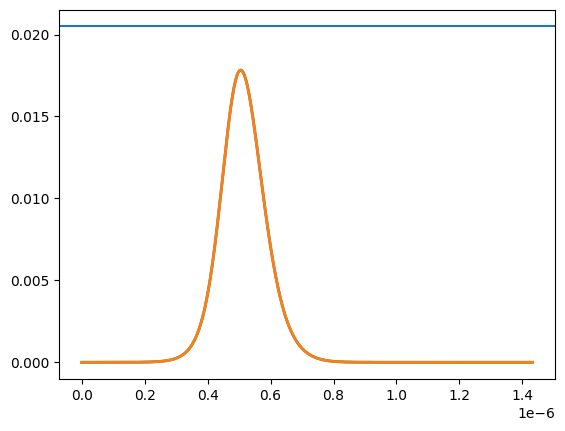

In [160]:
using Statistics
using Interpolations

N = 100000000
Γ = 1.0
ζ = N * 0.7
γ = 0.0
α = 0.2

nruns = 1000
cb = TerminateSteadyState(1e-2, 1e-4)
p = [Γ, ζ, N, γ]

switch_times = Float64[]
shifted_ts = Vector{Vector{Float64}}()
shifted_Is = Vector{Vector{Float64}}()

tmax_global = 0.0
intens(S,M) = S*(S+1)-M*(M+1)

for run = 1:nruns
    times, res = run_trajectory(N, Γ, ζ, γ, N^α, (S, M, N, Γ, ξ) -> [S, M])

    tswitch = times[end]
    push!(switch_times, tswitch)

    # either use matched initial condition:
    Ss = first.(res)
    Ms = last.(res)
    u0 = [intens(Ss[end], Ms[end]) / N^2, Ms[end] / N]

    # or your fixed bulk seed:
    #u0 = [1.0 / N, 1 / 2]
    println(u0[2])

    prob = ODEProblem(meanfield_reduced!, u0, (0.0, 1e10), p)
    mfsol = solve(prob, AutoTsit5(Rosenbrock23()), callback=cb, reltol=1e-8, abstol=1e-10)

    t_shifted = mfsol.t .+ tswitch
    I_shifted = first.(mfsol.u)

    push!(shifted_ts, t_shifted)
    push!(shifted_Is, I_shifted)

    tmax_global = max(tmax_global, t_shifted[end])
end

# common lab-time grid
tgrid = range(0.0, tmax_global, length=2000)

I_mean_uncond = zeros(length(tgrid))
I_mean_cond   = zeros(length(tgrid))
counts        = zeros(Int, length(tgrid))

for k in 1:nruns
    t = shifted_ts[k]
    I = shifted_Is[k]

    itp = linear_interpolation(t, I, extrapolation_bc=0.0)

    vals = itp.(tgrid)

    # unconditional: trajectories not yet started contribute 0
    I_mean_uncond .+= vals

    # conditional: average only where this trajectory exists
    mask = (tgrid .>= first(t)) .& (tgrid .<= last(t))
    I_mean_cond .+= vals .* mask
    counts .+= mask
end

I_mean_uncond ./= nruns
I_mean_cond ./= max.(counts, 1)

plot(tgrid, I_mean_uncond, label="unconditional average", lw=2)
plot(tgrid, I_mean_cond, label="conditional average", lw=2, ls="-")
axhline(0.0205)

display(gcf())
close("all")

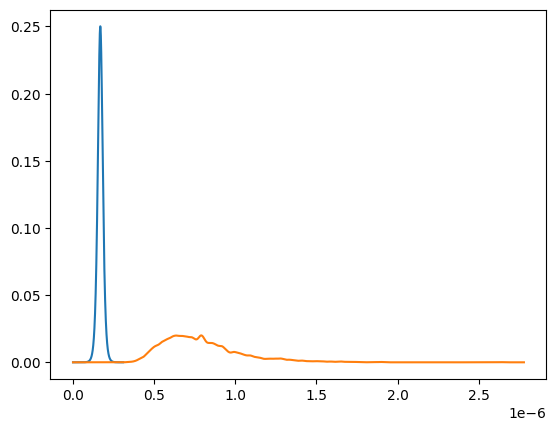

In [222]:
using Random

"""
    draw_tau0_n_marginal(λ, ζ, n_c; rng=Random.default_rng(), tmax=Inf)

Draw one switching time τ₀ from a Gillespie simulation of the marginal n-process

    n -> n+1   at rate λ (1+n)
    n -> n-1   at rate ζ n

starting from n(0)=0, and stopping at the first time n >= n_c.

Returns τ₀.

If tmax is reached before hitting n_c, returns Inf.
"""
function draw_tau0_n_marginal(λ, ζ, n_c; rng=Random.default_rng(), tmax=Inf)
    @assert λ > 0 "Need λ > 0"
    @assert ζ >= 0 "Need ζ >= 0"
    @assert n_c >= 1 "Need n_c >= 1"

    n = 0
    t = 0.0

    while n < n_c
        r_up = λ * (1 + n)
        r_down = ζ * n
        r_tot = r_up + r_down

        if r_tot <= 0
            return Inf
        end

        Δt = -log(rand(rng)) / r_tot
        t += Δt

        if t > tmax
            return Inf
        end

        if rand(rng) * r_tot < r_up
            n += 1
        else
            n -= 1
        end
    end

    return t
end

"""
    draw_tau0_n_marginal(λ, ζ, n_c, nsamples; rng=Random.default_rng(), tmax=Inf)

Draw `nsamples` independent switching times τ₀.
"""
function draw_tau0_n_marginal(λ, ζ, n_c, nsamples; rng=Random.default_rng(), tmax=Inf)
    τ = Vector{Float64}(undef, nsamples)
    for i in 1:nsamples
        τ[i] = draw_tau0_n_marginal(λ, ζ, n_c; rng=rng, tmax=tmax)
    end
    return τ
end

function meanfield_log_transformed!(du, u, p, t)
    L, m = u  # u[1] is log(I)
    Γ, ξ, N, γ = p

    # d(log I)/dt = (1/I) * dI/dt
    du[1] = (2 * N * Γ * m - ξ - γ)
    
    # dm/dt uses exp(L) to get the current intensity
    # We cap exp(L) at a reasonable max to prevent Inf during transients
    I_current = exp(L)
    du[2] = -N * Γ * I_current - γ * (m + 0.5)
end

N = 100000000
Γ = 1.0
ζ = N * 0.95
γ = N * 0.0
α = 0.3
τs = draw_tau0_n_marginal(N + γ, ζ, N^α, 2000)

cb = TerminateSteadyState(1e-1, 1e-1)
p = [Γ, ξ, N, γ]
u0 = [-log(N)+log(nc), 0.5]
prob = ODEProblem(meanfield_log_transformed!, u0, (0.0, 1e15), p)
sol = solve(prob, Rosenbrock23(), callback=cb, reltol=1e-8, abstol=1e-10)


ts_mf = sol.t[1:end-20]
Is_mf = [exp(u[1]) for u in sol.u][1:end-20]

interp_I = LinearInterpolation(ts_mf, Is_mf; extrapolation_bc=0.0)

tgrid = range(0.0, maximum(τs) + maximum(ts_mf), length=2000)

Iavg = zeros(length(tgrid))
for τ in τs
    Iavg .+= [t >= τ ? interp_I(t - τ) : 0.0 for t in tgrid]
end
Iavg ./= length(τs)

plot(ts_mf, Is_mf)
plot(tgrid, Iavg)
#axhline(0.196)
display(gcf())
close("all")

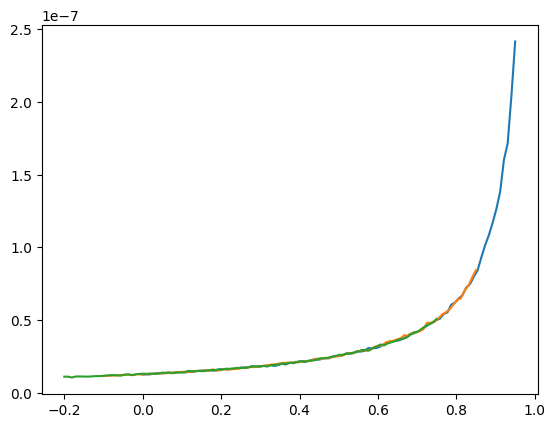

In [242]:
using StatsBase

gs = [0.0, 0.1, 0.2]

for g in gs
    γ = g * N
    res = []
    rs = range(0.0, 0.95, 100)
    for r in rs
        τs = draw_tau0_n_marginal(N + γ, r * N, N^α, 4000)
        push!(res, std(τs))
    end
    plot(rs .- g, res)
end

display(gcf())
close("all")

1.202275614747104
1.2565177314459937
1.2624154955014957


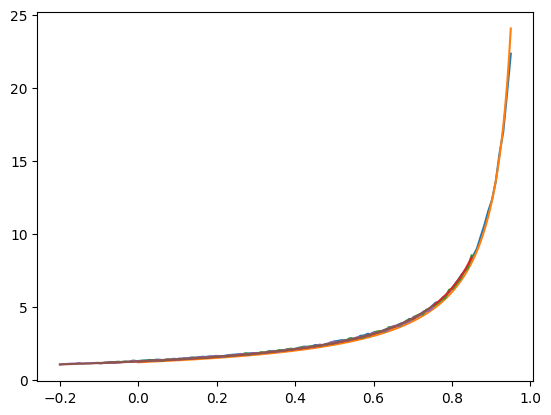

In [253]:
using LsqFit

N = 10000000
α = 0.3

for g in gs
    γ = g * N
    res = []
    rs = range(0.0, 0.95, 100)
    for r in rs
        τs = draw_tau0_n_marginal(N + γ, r * N, N^α, 4000)
        push!(res, std(τs))
    end

    x = rs .- g
    y = res

    model(x, p) = p[1] ./ (1 .- x)
    fit = curve_fit(model, x, y, [1.0])
    a = fit.param[1]
    println(a * N)

    xs = range(minimum(x), maximum(x), length=200)

    plot(x, y * N)
    plot(xs, N * a ./ (1 .- xs))
end

display(gcf())
close("all")